In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Anwendungsprojekt Colab - Unfall /Traffic_Crashes_2023-2025.csv")

Mounted at /content/drive


# **Missing Values**
Der folgende Code listet alle Spalten mit fehlenden Werten und listet sie nach ihrer Anzahl in absteigender Reihenfolge

Fehlende Werte pro Spalte:
LANE_CNT                         331889
WORKERS_PRESENT_I                331549
WORK_ZONE_TYPE                   330858
DOORING_I                        330794
WORK_ZONE_I                      330422
PHOTOS_TAKEN_I                   325923
STATEMENTS_TAKEN_I               321983
NOT_RIGHT_OF_WAY_I               318422
CRASH_DATE_EST_I                 310030
INTERSECTION_RELATED_I           255109
HIT_AND_RUN_I                    225127
REPORT_TYPE                       15015
LATITUDE                           3386
LOCATION                           3386
LONGITUDE                          3386
MOST_SEVERE_INJURY                  726
INJURIES_TOTAL                      723
INJURIES_FATAL                      723
INJURIES_INCAPACITATING             723
INJURIES_NO_INDICATION              723
INJURIES_REPORTED_NOT_EVIDENT       723
INJURIES_NON_INCAPACITATING         723
INJURIES_UNKNOWN                    723
dtype: int64


/tmp/ipykernel_1953/2190749833.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette='viridis')


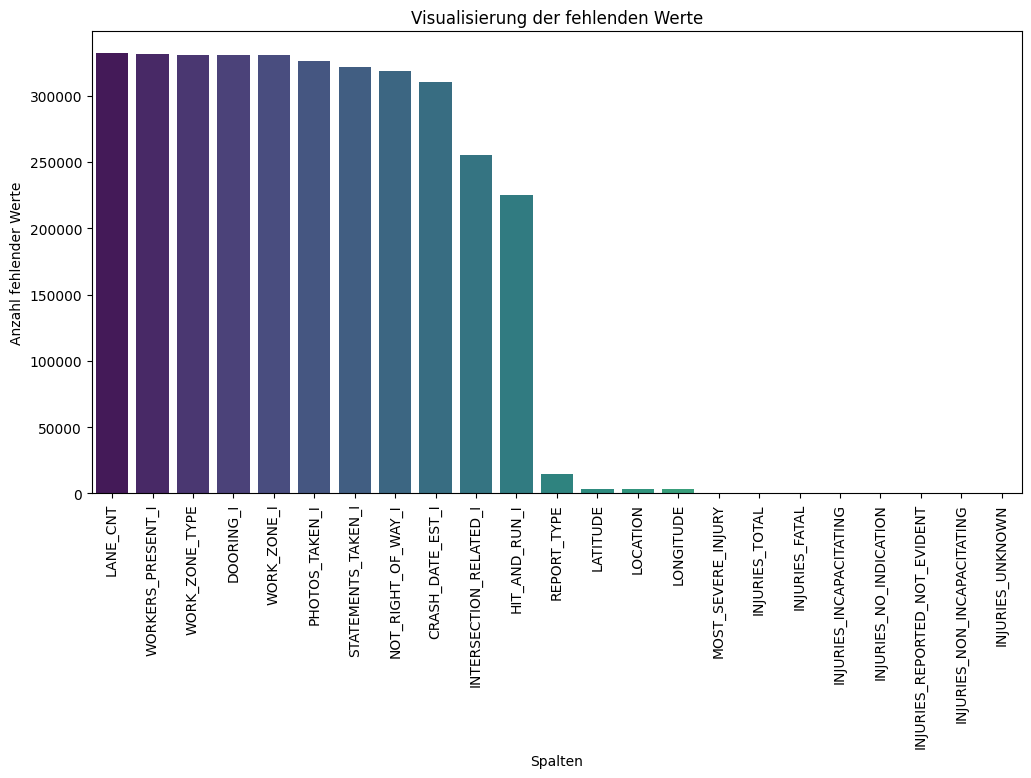

Grafik erfolgreich als SVG gespeichert unter: /content/drive/MyDrive/Anwendungsprojekt Colab - Unfall /missing_values_plot.svg


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der fehlenden Werte
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# Konsolenausgabe
print("Fehlende Werte pro Spalte:")
print(missing)

# Grafische Darstellung
if not missing.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing.index, y=missing.values, palette='viridis')
    plt.xticks(rotation=90)
    plt.xlabel('Spalten')
    plt.ylabel('Anzahl fehlender Werte')
    plt.title('Visualisierung der fehlenden Werte')
    output_path = "/content/drive/MyDrive/Anwendungsprojekt Colab - Unfall /missing_values_plot.svg"
    plt.savefig(output_path, format='svg', bbox_inches='tight')
    plt.show()
    print(f"Grafik erfolgreich als SVG gespeichert unter: {output_path}")
    plt.show()
else:
    print("Keine fehlenden Werte im aktuellen Datensatz gefunden.")

## **Dublettenprüfung**

In [ ]:
duplicates = df.duplicated().sum()

print(duplicates)

0


## **Lane_CNT**
Vergleicht LANE_CNT und TRAFFICWAY_TYPE um zu prüfen, ob ein fehlender Wert in der SPalte LANE_CNT als 0 und damit als Kreuzung zuinterpretieren ist

In [ ]:
missing_lane_cnt_df = df[df['LANE_CNT'].isnull()]

print(f"Number of rows with missing LANE_CNT: {len(missing_lane_cnt_df)}")

# Check how many of these rows have 'INTERSECTION' in TRAFFICWAY_TYPE
intersection_in_trafficway = missing_lane_cnt_df['TRAFFICWAY_TYPE'].str.contains('INTERSECTION', case=False, na=False).sum()

print(f"Number of rows with missing LANE_CNT where TRAFFICWAY_TYPE contains 'INTERSECTION': {intersection_in_trafficway}")

# Optionally, display the value counts of TRAFFICWAY_TYPE for these rows
print("\nValue counts of TRAFFICWAY_TYPE for rows with missing LANE_CNT:")
print(missing_lane_cnt_df['TRAFFICWAY_TYPE'].value_counts())

Number of rows with missing LANE_CNT: 331889
Number of rows with missing LANE_CNT where TRAFFICWAY_TYPE contains 'INTERSECTION': 10335

Value counts of TRAFFICWAY_TYPE for rows with missing LANE_CNT:
TRAFFICWAY_TYPE
NOT DIVIDED                        132986
DIVIDED - W/MEDIAN (NOT RAISED)     45032
FOUR WAY                            41883
ONE-WAY                             38522
PARKING LOT                         21437
DIVIDED - W/MEDIAN BARRIER          16656
OTHER                                8515
T-INTERSECTION                       7988
ALLEY                                5507
UNKNOWN                              4718
CENTER TURN LANE                     1800
UNKNOWN INTERSECTION TYPE            1401
RAMP                                 1040
DRIVEWAY                              938
TRAFFIC ROUTE                         924
FIVE POINT, OR MORE                   920
Y-INTERSECTION                        845
NOT REPORTED                          484
ROUNDABOUT                  

## **Spalten löschen**
diese Spalten schließen wir von unserer Ananlyse aus und löschen sie:
'LANE_CNT', 'HIT_AND_RUN_I', 'REPORT_TYPE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I

In [ ]:
columns_to_drop = ['LANE_CNT', 'HIT_AND_RUN_I', 'REPORT_TYPE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DATE_POLICE_NOTIFIED', 'BEAT_OF_OCCURRENCE' ]
df.drop(columns=columns_to_drop, inplace=True)

print(f"Columns dropped: {columns_to_drop}")
print("Updated DataFrame info:")
df.info()

Columns dropped: ['LANE_CNT', 'HIT_AND_RUN_I', 'REPORT_TYPE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DATE_POLICE_NOTIFIED', 'BEAT_OF_OCCURRENCE']
Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331922 entries, 0 to 331921
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_RECORD_ID                331922 non-null  object 
 1   CRASH_DATE_EST_I               21892 non-null   object 
 2   CRASH_DATE                     331922 non-null  object 
 3   POSTED_SPEED_LIMIT             331922 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         331922 non-null  object 
 5   DEVICE_CONDITION               331922 non-null  object 
 6   WEATHER_CONDITION              331922 non-null  object 
 7   LIGHTING_CONDITION             331922 non-null  object 
 8   FIRST_CRASH_TYPE               331922 non-null  object 
 9   TRAFFICWAY_TYPE                331922 non

## **Baustellenbezogene Spalten**
Die Analyse und dann MV-Behandlung der drei baustellenbezogenen Spalten

In [ ]:
print(df['WORKERS_PRESENT_I'].value_counts(dropna=False))
missing_workers_present = df['WORKERS_PRESENT_I'].isnull().sum()
total_rows = len(df)
percentage = (missing_workers_present / total_rows) * 100
print(f"\nMissing values in WORKERS_PRESENT_I: {missing_workers_present} ({percentage:.2f}%)")

print(df['WORK_ZONE_TYPE'].value_counts(dropna=False))
missing_work_zone_type = df['WORK_ZONE_TYPE'].isnull().sum()
total_rows = len(df)
percentage = (missing_work_zone_type / total_rows) * 100
print(f"\nMissing values in WORK_ZONE_TYPE: {missing_work_zone_type} ({percentage:.2f}%)")

print(df['WORK_ZONE_I'].value_counts(dropna=False))
missing_work_zone_i = df['WORK_ZONE_I'].isnull().sum()
total_rows = len(df)
percentage = (missing_work_zone_i / total_rows) * 100
print(f"\nMissing values in WORK_ZONE_I: {missing_work_zone_i} ({percentage:.2f}%)")

WORKERS_PRESENT_I
NaN    331549
Y         328
N          45
Name: count, dtype: int64

Missing values in WORKERS_PRESENT_I: 331549 (99.89%)
WORK_ZONE_TYPE
NaN             330858
CONSTRUCTION       731
UNKNOWN            167
MAINTENANCE        112
UTILITY             54
Name: count, dtype: int64

Missing values in WORK_ZONE_TYPE: 330858 (99.68%)
WORK_ZONE_I
NaN    330422
Y        1064
N         436
Name: count, dtype: int64

Missing values in WORK_ZONE_I: 330422 (99.55%)


In [ ]:
work_zone_columns = [
    'WORK_ZONE_I',
    'WORKERS_PRESENT_I',
    'WORK_ZONE_TYPE'
]

# Get the set of indices for rows with missing values for each column
missing_indices_work_zone = {col: set(df[df[col].isnull()].index) for col in work_zone_columns}

# Check if all these sets are identical
all_identical_work_zone = True
if len(missing_indices_work_zone) > 1:
    first_set_work_zone = next(iter(missing_indices_work_zone.values()))
    for col, current_set in missing_indices_work_zone.items():
        if current_set != first_set_work_zone:
            all_identical_work_zone = False
            break

if all_identical_work_zone:
    print(f"All work zone related columns ({', '.join(work_zone_columns)}) have missing values in the exact same rows.")
    print(f"Number of rows with missing work zone data: {len(first_set_work_zone)}")
else:
    print("The missing values in the work zone related columns are NOT perfectly correlated. Let's see the overlaps:")

    # Calculate overlaps and differences
    missing_work_zone_i = missing_indices_work_zone['WORK_ZONE_I']
    missing_workers_present_i = missing_indices_work_zone['WORKERS_PRESENT_I']
    missing_work_zone_type = missing_indices_work_zone['WORK_ZONE_TYPE']

    print(f"\nNumber of missing values in WORK_ZONE_I: {len(missing_work_zone_i)}")
    print(f"Number of missing values in WORKERS_PRESENT_I: {len(missing_workers_present_i)}")
    print(f"Number of missing values in WORK_ZONE_TYPE: {len(missing_work_zone_type)}")

    # Overlap between all three
    overlap_all = missing_work_zone_i.intersection(missing_workers_present_i, missing_work_zone_type)
    print(f"\nOverlap (rows missing all three): {len(overlap_all)}")

    # Check if a row missing WORK_ZONE_I is also missing the others
    work_zone_i_only_missing = missing_work_zone_i - (missing_workers_present_i.union(missing_work_zone_type))
    print(f"Rows where ONLY WORK_ZONE_I is missing: {len(work_zone_i_only_missing)}")

    # Check if a row missing WORKERS_PRESENT_I is also missing the others
    workers_present_i_only_missing = missing_workers_present_i - (missing_work_zone_i.union(missing_work_zone_type))
    print(f"Rows where ONLY WORKERS_PRESENT_I is missing: {len(workers_present_i_only_missing)}")

    # Check if a row missing WORK_ZONE_TYPE is also missing the others
    work_zone_type_only_missing = missing_work_zone_type - (missing_work_zone_i.union(missing_workers_present_i))
    print(f"Rows where ONLY WORK_ZONE_TYPE is missing: {len(work_zone_type_only_missing)}")

    # Specific overlaps (e.g., missing WORK_ZONE_I and WORKERS_PRESENT_I, but not WORK_ZONE_TYPE)
    overlap_WZ_WP = missing_work_zone_i.intersection(missing_workers_present_i) - missing_work_zone_type
    print(f"Rows missing WORK_ZONE_I and WORKERS_PRESENT_I but NOT WORK_ZONE_TYPE: {len(overlap_WZ_WP)}")

    overlap_WZ_WZT = missing_work_zone_i.intersection(missing_work_zone_type) - missing_workers_present_i
    print(f"Rows missing WORK_ZONE_I and WORK_ZONE_TYPE but NOT WORKERS_PRESENT_I: {len(overlap_WZ_WZT)}")

    overlap_WP_WZT = missing_workers_present_i.intersection(missing_work_zone_type) - missing_work_zone_i
    print(f"Rows missing WORKERS_PRESENT_I and WORK_ZONE_TYPE but NOT WORK_ZONE_I: {len(overlap_WP_WZT)}")


The missing values in the work zone related columns are NOT perfectly correlated. Let's see the overlaps:

Number of missing values in WORK_ZONE_I: 330422
Number of missing values in WORKERS_PRESENT_I: 331549
Number of missing values in WORK_ZONE_TYPE: 330858

Overlap (rows missing all three): 330422
Rows where ONLY WORK_ZONE_I is missing: 0
Rows where ONLY WORKERS_PRESENT_I is missing: 691
Rows where ONLY WORK_ZONE_TYPE is missing: 0
Rows missing WORK_ZONE_I and WORKERS_PRESENT_I but NOT WORK_ZONE_TYPE: 0
Rows missing WORK_ZONE_I and WORK_ZONE_TYPE but NOT WORKERS_PRESENT_I: 0
Rows missing WORKERS_PRESENT_I and WORK_ZONE_TYPE but NOT WORK_ZONE_I: 436


## **MV-Behandlung von baustellenbezogenen Spalten**

In [ ]:
all_three_missing_mask = df['WORK_ZONE_I'].isnull() & df['WORKERS_PRESENT_I'].isnull() & df['WORK_ZONE_TYPE'].isnull()

# Apply imputation for rows where all three are missing
df.loc[all_three_missing_mask, 'WORK_ZONE_I'] = df.loc[all_three_missing_mask, 'WORK_ZONE_I'].fillna('N')
df.loc[all_three_missing_mask, 'WORKERS_PRESENT_I'] = df.loc[all_three_missing_mask, 'WORKERS_PRESENT_I'].fillna('Not Applicable')
df.loc[all_three_missing_mask, 'WORK_ZONE_TYPE'] = df.loc[all_three_missing_mask, 'WORK_ZONE_TYPE'].fillna('Not Applicable')

print("After imputation for cases where all three work zone columns were missing:")

print("\nWORKERS_PRESENT_I value counts:")
print(df['WORKERS_PRESENT_I'].value_counts(dropna=False))
missing_workers_present = df['WORKERS_PRESENT_I'].isnull().sum()
total_rows = len(df)
percentage = (missing_workers_present / total_rows) * 100
print(f"Missing values in WORKERS_PRESENT_I: {missing_workers_present} ({percentage:.2f}%)")

print("\nWORK_ZONE_TYPE value counts:")
print(df['WORK_ZONE_TYPE'].value_counts(dropna=False))
missing_work_zone_type = df['WORK_ZONE_TYPE'].isnull().sum()
percentage = (missing_work_zone_type / total_rows) * 100
print(f"Missing values in WORK_ZONE_TYPE: {missing_work_zone_type} ({percentage:.2f}%)")

print("\nWORK_ZONE_I value counts:")
print(df['WORK_ZONE_I'].value_counts(dropna=False))
missing_work_zone_i = df['WORK_ZONE_I'].isnull().sum()
percentage = (missing_work_zone_i / total_rows) * 100
print(f"Missing values in WORK_ZONE_I: {missing_work_zone_i} ({percentage:.2f}%)")

# Verify the special cases are still present and unchanged where applicable
# This is implicitly handled as the imputation mask only targets rows where ALL three were NaN.
# For example, the 691 cases where only WORKERS_PRESENT_I was missing will still have NaNs in WORKERS_PRESENT_I
# The 436 cases where WORKERS_PRESENT_I and WORK_ZONE_TYPE were missing but WORK_ZONE_I was present will still have NaNs in those two columns

After imputation for cases where all three work zone columns were missing:

WORKERS_PRESENT_I value counts:
WORKERS_PRESENT_I
Not Applicable    330422
NaN                 1127
Y                    328
N                     45
Name: count, dtype: int64
Missing values in WORKERS_PRESENT_I: 1127 (0.34%)

WORK_ZONE_TYPE value counts:
WORK_ZONE_TYPE
Not Applicable    330422
CONSTRUCTION         731
NaN                  436
UNKNOWN              167
MAINTENANCE          112
UTILITY               54
Name: count, dtype: int64
Missing values in WORK_ZONE_TYPE: 436 (0.13%)

WORK_ZONE_I value counts:
WORK_ZONE_I
N    330858
Y      1064
Name: count, dtype: int64
Missing values in WORK_ZONE_I: 0 (0.00%)


## **MV-Behandlung von Dooring**

In [ ]:
df['DOORING_I'].fillna('N', inplace=True)
print("Missing values in 'DOORING_I' after imputation:")
print(df['DOORING_I'].isnull().sum())

Missing values in 'DOORING_I' after imputation:
0


/tmp/ipykernel_1953/2213388417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DOORING_I'].fillna('N', inplace=True)


## **MV-Behandlung von not right of way**

In [ ]:
df['NOT_RIGHT_OF_WAY_I'].fillna('N', inplace=True)
print("Missing values in 'NOT_RIGHT_OF_WAY_I' after imputation:")
print(df['NOT_RIGHT_OF_WAY_I'].isnull().sum())

Missing values in 'NOT_RIGHT_OF_WAY_I' after imputation:
0


/tmp/ipykernel_1953/3944276089.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NOT_RIGHT_OF_WAY_I'].fillna('N', inplace=True)


## **MV-Behandlung von Crash Date Est**

In [ ]:
df['CRASH_DATE_EST_I'].fillna('N', inplace=True)
print("Missing values in 'CRASH_DATE_EST_I' after imputation:")
print(df['CRASH_DATE_EST_I'].isnull().sum())

Missing values in 'CRASH_DATE_EST_I' after imputation:
0


/tmp/ipykernel_1953/4085201044.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CRASH_DATE_EST_I'].fillna('N', inplace=True)


## **MV-Behandlung von Intersection related**

In [ ]:
df['INTERSECTION_RELATED_I'].fillna('N', inplace=True)
print("Missing values in 'INTERSECTION_RELATED_I' after imputation:")
print(df['INTERSECTION_RELATED_I'].isnull().sum())

Missing values in 'INTERSECTION_RELATED_I' after imputation:
0


/tmp/ipykernel_1953/1399243108.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['INTERSECTION_RELATED_I'].fillna('N', inplace=True)


## **Analyse von Latitude, Location und Longitude**

In [ ]:
missing_latitude_df = df[df['LATITUDE'].isnull()]
missing_longitude_df = df[df['LONGITUDE'].isnull()]
missing_location_df = df[df['LOCATION'].isnull()]

if (missing_latitude_df['LOCATION'].isnull().all() and missing_latitude_df['LONGITUDE'].isnull().all()):
    print("\nAll rows with missing LATITUDE also have missing LOCATION and LONGITUDE.")
else:
    print("\nNot all rows with missing LATITUDE have missing LOCATION and LONGITUDE.")

if (missing_longitude_df['LATITUDE'].isnull().all() and missing_longitude_df['LOCATION'].isnull().all()):
    print("All rows with missing LONGITUDE also have missing LATITUDE and LOCATION.")
else:
    print("Not all rows with missing LONGITUDE have missing LATITUDE and LOCATION.")

if (missing_location_df['LATITUDE'].isnull().all() and missing_location_df['LONGITUDE'].isnull().all()):
    print("All rows with missing LOCATION also have missing LATITUDE and LONGITUDE.")
else:
    print("Not all rows with missing LOCATION have missing LATITUDE and LONGITUDE.")


All rows with missing LATITUDE also have missing LOCATION and LONGITUDE.
All rows with missing LONGITUDE also have missing LATITUDE and LOCATION.
All rows with missing LOCATION also have missing LATITUDE and LONGITUDE.


## **MV-Behandlung von Location**
Die ca. 3.400 Zeilen, in denen alle drei Variablen fehlen, werden gelöscht

In [ ]:
initial_rows = len(df)

# Create a mask for rows where all three columns are NaN
all_location_nan_mask = df['LOCATION'].isnull() & \
                         df['LATITUDE'].isnull() & \
                         df['LONGITUDE'].isnull()

# Drop rows where the mask is True
df.drop(df[all_location_nan_mask].index, inplace=True)

rows_dropped = initial_rows - len(df)

print(f"Number of rows dropped (missing all three location columns): {rows_dropped}")
print(f"Remaining rows in DataFrame: {len(df)}")

print("\nMissing values in Location columns after dropping:")
print(f"LATITUDE missing: {df['LATITUDE'].isnull().sum()}")
print(f"LONGITUDE missing: {df['LONGITUDE'].isnull().sum()}")
print(f"LOCATION missing: {df['LOCATION'].isnull().sum()}")

Number of rows dropped (missing all three location columns): 3386
Remaining rows in DataFrame: 328536

Missing values in Location columns after dropping:
LATITUDE missing: 0
LONGITUDE missing: 0
LOCATION missing: 0


## **Analyse von den verletzungsbezogenen Spalten**

In [ ]:
injury_columns = [
    'MOST_SEVERE_INJURY',
    'INJURIES_TOTAL',
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NO_INDICATION',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_UNKNOWN'
]

# Get the set of indices for rows with missing values for each column
missing_indices = {col: set(df[df[col].isnull()].index) for col in injury_columns}

# Check if all these sets are identical
all_identical = True
if len(missing_indices) > 1:
    first_set = next(iter(missing_indices.values()))
    for col, current_set in missing_indices.items():
        if current_set != first_set:
            all_identical = False
            break

if all_identical:
    print(f"All injury-related columns ({', '.join(injury_columns)}) have missing values in the exact same rows.")
    print(f"Number of rows with missing injury data: {len(first_set)}")
else:
    print("The missing values in the injury-related columns are NOT perfectly correlated.")

The missing values in the injury-related columns are NOT perfectly correlated.


WIr gucken uns die drei Zeilen die in most severe injury fehlen, aber die anderen verletzungsbezogenen Spalten keine fehlende Werte haben

In [ ]:
injury_columns_except_most_severe = [
    'INJURIES_TOTAL',
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NO_INDICATION',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_UNKNOWN'
]

# Get indices where MOST_SEVERE_INJURY is missing
missing_most_severe_indices = set(df[df['MOST_SEVERE_INJURY'].isnull()].index)

# Get indices where ANY of the other injury columns are missing
missing_other_injuries_indices = set()
for col in injury_columns_except_most_severe:
    missing_other_injuries_indices.update(set(df[df[col].isnull()].index))

# Find the indices that are in missing_most_severe_indices but not in missing_other_injuries_indices
different_missing_indices = missing_most_severe_indices - missing_other_injuries_indices

print(f"Number of rows where ONLY MOST_SEVERE_INJURY is missing: {len(different_missing_indices)}")

if len(different_missing_indices) > 0:
    print("\nThese are the rows where MOST_SEVERE_INJURY is missing, but other injury columns are present:")
    display(df.loc[list(different_missing_indices), ['MOST_SEVERE_INJURY'] + injury_columns_except_most_severe])
else:
    print("No rows found where only MOST_SEVERE_INJURY is missing and other injury columns are present.")

Number of rows where ONLY MOST_SEVERE_INJURY is missing: 3

These are the rows where MOST_SEVERE_INJURY is missing, but other injury columns are present:


,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NO_INDICATION,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NON_INCAPACITATING,INJURIES_UNKNOWN
192083,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
139499,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
258327,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Da alle verletzungsbezogenen Spalten 0 eingetragen haben, bedeutet das wohl, dass es keine Verletzungen gab. Deswegen werden wir dies in die drei Zeilen einfügen.

In [ ]:
if len(different_missing_indices) > 0:
    df.loc[list(different_missing_indices), 'MOST_SEVERE_INJURY'] = 'NO INDICATION OF INJURY'
    print(f"Imputed {len(different_missing_indices)} rows in 'MOST_SEVERE_INJURY' with 'NO INDICATION OF INJURY'.")
else:
    print("No rows found where only MOST_SEVERE_INJURY was missing. No imputation performed for these specific cases.")

print("\nMissing values in 'MOST_SEVERE_INJURY' after specific imputation:")
print(df['MOST_SEVERE_INJURY'].isnull().sum())

Imputed 3 rows in 'MOST_SEVERE_INJURY' with 'NO INDICATION OF INJURY'.

Missing values in 'MOST_SEVERE_INJURY' after specific imputation:
718


In [ ]:
injury_columns_to_check = [
    'MOST_SEVERE_INJURY',
    'INJURIES_TOTAL',
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NO_INDICATION',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_UNKNOWN'
]

print("Missing values for injury-related columns:")
for col in injury_columns_to_check:
    missing_count = df[col].isnull().sum()
    print(f"{col}: {missing_count}")

Missing values for injury-related columns:
MOST_SEVERE_INJURY: 718
INJURIES_TOTAL: 718
INJURIES_FATAL: 718
INJURIES_INCAPACITATING: 718
INJURIES_NO_INDICATION: 718
INJURIES_REPORTED_NOT_EVIDENT: 718
INJURIES_NON_INCAPACITATING: 718
INJURIES_UNKNOWN: 718


In [ ]:
injury_columns_for_total_check = [
    'MOST_SEVERE_INJURY',
    'INJURIES_TOTAL',
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NO_INDICATION',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_UNKNOWN'
]

# Initialize an empty set to store unique indices of rows with missing values
all_missing_injury_indices = set()

# Iterate through each injury column and add the indices of missing values to the set
for col in injury_columns_for_total_check:
    missing_col_indices = set(df[df[col].isnull()].index)
    all_missing_injury_indices.update(missing_col_indices)

print(f"Total number of unique rows with missing values in at least one injury column: {len(all_missing_injury_indices)}")

Total number of unique rows with missing values in at least one injury column: 718


In [ ]:
injury_columns_to_drop_missing = [
    'MOST_SEVERE_INJURY',
    'INJURIES_TOTAL',
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NO_INDICATION',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_UNKNOWN'
]

initial_rows = len(df)

# Create a boolean mask for rows where ANY of the specified injury columns are NaN
# Since we previously confirmed all these columns have missing values in the same rows (718),
# checking just one column or using .any() will achieve the same result.
missing_injury_mask = df[injury_columns_to_drop_missing].isnull().any(axis=1)

# Drop these rows from the DataFrame
df.drop(df[missing_injury_mask].index, inplace=True)

rows_dropped = initial_rows - len(df)

print(f"Number of rows dropped (missing values in injury columns): {rows_dropped}")
print(f"Remaining rows in DataFrame: {len(df)}")

print("\nMissing values in injury columns after dropping:")
for col in injury_columns_to_drop_missing:
    missing_count = df[col].isnull().sum()
    print(f"{col}: {missing_count}")

Number of rows dropped (missing values in injury columns): 718
Remaining rows in DataFrame: 327818

Missing values in injury columns after dropping:
MOST_SEVERE_INJURY: 0
INJURIES_TOTAL: 0
INJURIES_FATAL: 0
INJURIES_INCAPACITATING: 0
INJURIES_NO_INDICATION: 0
INJURIES_REPORTED_NOT_EVIDENT: 0
INJURIES_NON_INCAPACITATING: 0
INJURIES_UNKNOWN: 0


# **Feature Engeneering**

## **FE - One Hot Encoding**
Im folgenden Code werden alle Spalten, welche Y der N Werte enthalten im Feature Engeneering verfahren zu 0 und 1 geändert

In [ ]:
columns_to_convert_yn = ['CRASH_DATE_EST_I', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'DOORING_I', 'WORK_ZONE_I']

for col in columns_to_convert_yn:

    if col in df.columns:
        # Check for unique values before conversion to avoid errors if only numeric values are present
        unique_values = df[col].unique()
        if 'Y' in unique_values or 'N' in unique_values:
            # Handle potential 'Not Applicable' or other non-Y/N values if they exist after previous imputation
            # Map 'Y' to 1, 'N' to 0, and keep other values as they are, then convert to int
            df[col] = df[col].apply(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))
            # Convert to integer, coercing errors for any remaining non-numeric values if necessary
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int) # Fill NaNs (if any after coerce) with 0
            print(f"Value counts for '{col}' after conversion:")
            print(df[col].value_counts())
            print(f"Data type for '{col}' after conversion:")
            print(df[col].dtype)
            print("\n" + "-" * 30 + "\n") # Separator for readability
        else:
            print(f"Column '{col}' does not contain 'Y' or 'N' for conversion, skipping.\n" + "-" * 30 + "\n")
    else:
        print(f"Column '{col}' not found in DataFrame, skipping.\n" + "-" * 30 + "\n")

Value counts for 'CRASH_DATE_EST_I' after conversion:
CRASH_DATE_EST_I
0    309010
1     18808
Name: count, dtype: int64
Data type for 'CRASH_DATE_EST_I' after conversion:
int64

------------------------------

Value counts for 'INTERSECTION_RELATED_I' after conversion:
INTERSECTION_RELATED_I
0    255362
1     72456
Name: count, dtype: int64
Data type for 'INTERSECTION_RELATED_I' after conversion:
int64

------------------------------

Value counts for 'NOT_RIGHT_OF_WAY_I' after conversion:
NOT_RIGHT_OF_WAY_I
0    315839
1     11979
Name: count, dtype: int64
Data type for 'NOT_RIGHT_OF_WAY_I' after conversion:
int64

------------------------------

Value counts for 'DOORING_I' after conversion:
DOORING_I
0    327065
1       753
Name: count, dtype: int64
Data type for 'DOORING_I' after conversion:
int64

------------------------------

Value counts for 'WORK_ZONE_I' after conversion:
WORK_ZONE_I
0    326776
1      1042
Name: count, dtype: int64
Data type for 'WORK_ZONE_I' after conversi

## **FE-Datum - Im Folgenden Code wird das Daturm in Jahr und Tag extrahiert.**

In [ ]:
# 1. Sicherstellen, dass die Spalte im richtigen Datetime-Format vorliegt
df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'])

# 2. Feature Engineering: Extrahieren von Jahr und Tag
df['CRASH_YEAR'] = df['CRASH_DATE'].dt.year
df['CRASH_DAY'] = df['CRASH_DATE'].dt.day

# 3. Profi-Tipp für Unfalldaten: Wochentag (0=Montag, 6=Sonntag)
# df['CRASH_DAY_OF_WEEK'] = df['CRASH_DATE'].dt.dayofweek


/tmp/ipykernel_1953/1416993987.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'])


## FE - Speed - Im folgenden Code wird die ausgeschilderte Geschwindigkeit in Kategorien (Bins) unterteilt.


In [ ]:
# Bins exakt auf das Maximum von 70 mph angepasst:
# -1 bis 5  -> Anomalien / Schrittgeschwindigkeit (z.B. Parkplätze, Alleys)
# 5 bis 15  -> Sehr langsam (Schulzonen, verkehrsberuhigt)
# 15 bis 25 -> Wohngebiete (Typisch 20 oder 25 mph in Chicago)
# 25 bis 35 -> Der Chicagoer Stadt-Standard (Der Großteil ist exakt 30 mph)
# 35 bis 45 -> Große Durchgangsstraßen / Boulevards (40/45 mph)
# 45 bis 70 -> Highways / Expressways (50 bis 70 mph)

bins = [-1, 5, 15, 25, 35, 45, 70]
labels = ['Anomaly_or_Alley', 'Very_Low_Speed', 'Residential_Speed', 'City_Standard_30mph', 'Major_Avenue', 'Highway_Speed']

# Neue Spalte mit den korrigierten Bins erstellen
df['SPEED_CATEGORY'] = pd.cut(df['POSTED_SPEED_LIMIT'], bins=bins, labels=labels)

# One-Hot-Encoding für dein Machine-Learning-Modell
df_encoded = pd.get_dummies(df, columns=['SPEED_CATEGORY'], dtype=int)

Im folgenden Code wird die geschwindigkit multpliziert mit 0 bei vorhandener verkehrkontrolle und mit 1 bei nicht vorhandener Kontrolle. Daraus ensteht ein 2gefahr Faktoer...je höher die geschwindigkeit, desto höher die gefahr


In [ ]:
# 1. Schritt: Wir bestimmen zuerst, ob KEINE Verkehrsregelung vorliegt (1 = Keine Regelung, 0 = Es gibt ein Schild/Ampel)
# Dadurch wird die Multiplikation mathematisch korrekt: Hohes Tempo * 1 = Hohe Gefahr. Hohes Tempo * 0 = 0 Gefahr.
df['IS_NO_CONTROL'] = df['TRAFFIC_CONTROL_DEVICE'].apply(
    lambda x: 1 if 'NO CONTROLS' in str(x).upper() or 'UNKNOWN' in str(x).upper() else 0
)

# 2. Schritt: Der Interaktionsterm (Gefahren-Index)
# Wir multiplizieren das Tempolimit mit dem "Keine Regelung"-Flag
df['SPEED_X_NO_CONTROL'] = df['POSTED_SPEED_LIMIT'] * df['IS_NO_CONTROL']


# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DES GEFAHREN-INDEX ---")
# Wir lassen uns die relevanten Spalten für die ersten 10 Zeilen ausgeben
print(df[['POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'IS_NO_CONTROL', 'SPEED_X_NO_CONTROL']].head(10))

--- PRÜFUNG DES GEFAHREN-INDEX ---
   POSTED_SPEED_LIMIT TRAFFIC_CONTROL_DEVICE  IS_NO_CONTROL  \
0                  30      STOP SIGN/FLASHER              0   
1                  30         TRAFFIC SIGNAL              0   
2                  30         TRAFFIC SIGNAL              0   
3                  30            NO CONTROLS              1   
4                  30            NO CONTROLS              1   
5                  30         TRAFFIC SIGNAL              0   
6                  30            NO CONTROLS              1   
7                  30         TRAFFIC SIGNAL              0   
8                  30                UNKNOWN              1   
9                  40            NO CONTROLS              1   

   SPEED_X_NO_CONTROL  
0                   0  
1                   0  
2                   0  
3                  30  
4                  30  
5                   0  
6                  30  
7                   0  
8                  30  
9                  40  


## **FE - Geo Cluster**

 Die geografischen Daten (LATITUDE und LONGITUDE) bergen das größte Potenzial, um Mustern wie „Unfall-Hotspots“ auf die Spur zu kommen. Für ein Machine-Learning-Modell sind die reinen Koordinaten (wie $41.8906$) schwer zu interpretieren, da sich das Risiko im Stadtgebiet von Block zu Block drastisch ändert.Wir setzen jetzt den ersten Schritt um: Das Clustering (Hotspot-Erkennung) mittels K-Means.1. Das Konzept dahinterAnstatt dem Modell die exakten Koordinaten zu geben, teilen wir Chicago in $K$ logische Unfall-Zonen auf. K-Means analysiert alle Unfälle in deinem Datensatz und gruppiert sie automatisch nach räumlicher Nähe. Jeder Unfall erhält dann eine feste Zonen-ID (z. B. Zone 0 für Downtown, Zone 1 für South Side etc.).Da wir diese Kategorien danach in 0/1-Spalten umwandeln, kann dein Modell später blitzschnell lernen: „In Zone 3 ist das Unfallrisiko um 23:00 Uhr besonders hoch.

In [ ]:
from sklearn.cluster import KMeans

# 1. Nur die Zeilen filtern, die gültige Koordinaten enthalten
# (Manchmal gibt es Nullwerte in LATITUDE/LONGITUDE, die K-Means blockieren würden)
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

# 2. K-Means Modell definieren (wir erstellen 10 geografische Cluster)
# 'random_state' sorgt dafür, dass die Ergebnisse bei jedem Durchlauf exakt gleich bleiben
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)

# 3. Das Modell mit den Koordinaten trainieren und die Cluster-IDs vorhersagen
df['GEO_CLUSTER'] = kmeans.fit_predict(df[['LATITUDE', 'LONGITUDE']])

# 4. Die neuen Cluster-IDs in 0 und 1 Spalten für das ML-Modell umwandeln
df_encoded = pd.get_dummies(df, columns=['GEO_CLUSTER'], prefix='CLUSTER', dtype=int)

Zuordnung der Clustern zu ihren mittelpunkten.

In [ ]:
# Berechne den Mittelpunkt (Mittelwert) der Koordinaten für jedes Cluster
cluster_centers = df.groupby('GEO_CLUSTER')[['LATITUDE', 'LONGITUDE']].mean()
print("--- MITTELPUNKTE DER CLUSTER (Für Google Maps) ---")
for cluster_num, row in cluster_centers.iterrows():
   print(f"Cluster {cluster_num}: {row['LATITUDE']:.5f}, {row['LONGITUDE']:.5f} "
         f"-> (Kopiere '{row['LATITUDE']:.5f}, {row['LONGITUDE']:.5f}' in Google Maps!)")

--- MITTELPUNKTE DER CLUSTER (Für Google Maps) ---
Cluster 0: 41.73640, -87.57823 -> (Kopiere '41.73640, -87.57823' in Google Maps!)
Cluster 1: 0.00000, 0.00000 -> (Kopiere '0.00000, 0.00000' in Google Maps!)
Cluster 2: 41.90464, -87.73340 -> (Kopiere '41.90464, -87.73340' in Google Maps!)
Cluster 3: 41.95819, -87.78465 -> (Kopiere '41.95819, -87.78465' in Google Maps!)
Cluster 4: 41.84918, -87.69481 -> (Kopiere '41.84918, -87.69481' in Google Maps!)
Cluster 5: 41.97086, -87.68320 -> (Kopiere '41.97086, -87.68320' in Google Maps!)
Cluster 6: 41.78360, -87.72048 -> (Kopiere '41.78360, -87.72048' in Google Maps!)
Cluster 7: 41.71399, -87.65114 -> (Kopiere '41.71399, -87.65114' in Google Maps!)
Cluster 8: 41.79322, -87.62757 -> (Kopiere '41.79322, -87.62757' in Google Maps!)
Cluster 9: 41.88930, -87.64057 -> (Kopiere '41.88930, -87.64057' in Google Maps!)


## **FE - Straßenbedingungen -** Im folgenden Code wwerden die Wetterbedinung in 2 Zonen unterteilt: 0 bei guten bedingungen und 1 bei rutschigen bedingungen.


In [ ]:
# 1. Define groups for road conditions
dry_condition = 'DRY'
slippery_conditions = ['SNOW OR SLUSH', 'WET', 'ICE', 'MUDDY']
sand_mud_dirt_condition = ['SAND, MUD, DIRT']

# 2. Create a function to categorize road conditions into four groups
def categorize_road_conditions(condition):
    condition = str(condition).upper() # Ensure case-insensitivity and handle potential non-string types
    if condition == dry_condition:
        return 'DRY'
    elif condition in sand_mud_dirt_condition:
        return 'SAND_MUD_DIRT'
    elif condition in slippery_conditions:
        return 'SLIPPERY'
    else:
        return 'OTHER' # For conditions like 'UNKNOWN', 'NORMAL', etc.

# 3. Apply the function to create the new categorical feature
df['ROAD_COND_CATEGORY'] = df['ROADWAY_SURFACE_COND'].apply(categorize_road_conditions)

# 4. One-hot encode the new categorical feature
# This will replace the single 'ROAD_COND_CATEGORY' column with multiple binary columns
df = pd.get_dummies(df, columns=['ROAD_COND_CATEGORY'], prefix='ROAD_COND', dtype=int)

# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DER NEUEN STRASSENBEDINGUNGSKATEGORIEN ---")
# Filter for the original and newly created one-hot encoded columns
road_cond_cols = [col for col in df.columns if col.startswith('ROAD_COND_')]
print(df[['ROADWAY_SURFACE_COND'] + road_cond_cols].head(5))

--- PRÜFUNG DER NEUEN STRASSENBEDINGUNGSKATEGORIEN ---
  ROADWAY_SURFACE_COND  ROAD_COND_DRY  ROAD_COND_OTHER  \
0                  DRY              1                0   
1        SNOW OR SLUSH              0                0   
2              UNKNOWN              0                1   
3                  WET              0                0   
4              UNKNOWN              0                1   

   ROAD_COND_SAND_MUD_DIRT  ROAD_COND_SLIPPERY  
0                        0                   0  
1                        0                   1  
2                        0                   0  
3                        0                   1  
4                        0                   0  


In [ ]:
!pip install holidays

## **FE - Datums Bereiche**
Im Folgenen Code werden Daten in Bereiche unterteilt. Wie Rushhour, Weekend oder Holiday.  Bei holiday ist es nötig auch den vorabend zu analysieren - New Years Eve oder Christmas Eve

In [ ]:
import holidays
us_holidays = holidays.US()
def check_holiday_and_eve(row):
   try:
       # 1. Datum des aktuellen Unfalls bauen
       date_str = f"{int(row['CRASH_YEAR'])}-{int(row['CRASH_MONTH'])}-{int(row['CRASH_DAY'])}"
       date_obj = pd.to_datetime(date_str)
       # 2. Datum des NÄCHSTEN Tages berechnen
       next_day = date_obj + pd.Timedelta(days=1)
       # LOGIK-CHECK:
       # Ist HEUTE ein Feiertag? ODER ist MORGEN ein Feiertag (und heute somit Vorabend)?
       if date_obj in us_holidays or next_day in us_holidays:
           return 1
       else:
           return 0
   except:
       return 0
# Das neue, verbesserte Feature anwenden
df['IS_HOLIDAY_OR_EVE'] = df.apply(check_holiday_and_eve, axis=1)
# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DES OPTIMIERTEN FEIERTAG-FEATURES ---")
print(df[['CRASH_YEAR', 'CRASH_MONTH', 'CRASH_DAY', 'CRASH_HOUR', 'IS_HOLIDAY_OR_EVE']].head(2))

--- PRÜFUNG DES OPTIMIERTEN FEIERTAG-FEATURES ---
   CRASH_YEAR  CRASH_MONTH  CRASH_DAY  CRASH_HOUR  IS_HOLIDAY_OR_EVE
0        2025           12         31          23                  1
1        2025           12         31          23                  1


In [ ]:
# 1. Feature: Wochenende-Flag (Freitag=5, Samstag=6, Sonntag=7)
# Wir prüfen, ob der Wochentag in dieser Liste ist und konvertieren True/False zu 1/0
df['IS_WEEKEND'] = df['CRASH_DAY_OF_WEEK'].isin([5, 6, 7]).astype(int)

# 2. Feature: Tageszeit-Kategorien (Rushhour-Logik)
def get_time_of_day(hour):
   if 6 <= hour < 9:
       return 'rush_morning'
   elif 9 <= hour < 15:
       return 'midday'
   elif 15 <= hour < 19:
       return 'rush_evening'
   else:
       return 'night'
# Funktion auf die originale CRASH_HOUR anwenden
df['TIME_OF_DAY'] = df['CRASH_HOUR'].apply(get_time_of_day)

# 3. One-Hot-Encoding für die Tageszeit direkt in df_train durchführen
# Dadurch entstehen die Spalten TIME_rush_morning, TIME_midday, TIME_rush_evening, TIME_night
df = pd.get_dummies(df, columns=['TIME_OF_DAY'], prefix='TIME', dtype=int)

# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DER NEUEN ZEIT-FEATURES IM TRAININGS-DATENSATZ ---")
# Wir filtern die neu erstellten Spalten für die Anzeige heraus
time_cols = [col for col in df.columns if col.startswith('TIME_')]
print(df[['IS_WEEKEND'] + time_cols].head(2))

--- PRÜFUNG DER NEUEN ZEIT-FEATURES IM TRAININGS-DATENSATZ ---
   IS_WEEKEND  TIME_midday  TIME_night  TIME_rush_evening  TIME_rush_morning
0           0            0           1                  0                  0
1           0            0           1                  0                  0


FE - Lichtverhältnisse

In [ ]:
import pandas as pd

# 1. Bereinigungs- und Gruppierungsfunktion definieren
def categorize_lighting(light):
    light = str(light).upper()
    if 'DAYLIGHT' in light:
        return 'LIGHT_DAY'
    elif 'LIGHTED' in light:
        return 'LIGHT_DARK_BELIGHTED'
    elif 'DARKNESS' in light or 'UNKNOWN' in light:
        return 'LIGHT_DARK_POOR'
    elif 'DAWN' in light or 'DUSK' in light:
        return 'LIGHT_TWILIGHT' # Dämmerung
    else:
        return 'LIGHT_UNKNOWN'

# 2. Funktion auf die originale Spalte anwenden
df['LIGHT_GROUP'] = df['LIGHTING_CONDITION'].apply(categorize_lighting)

# 3. One-Hot-Encoding durchführen (erstellt Spalten wie LIGHT_LIGHT_DAY, LIGHT_LIGHT_DARK_POOR etc.)
df = pd.get_dummies(df, columns=['LIGHT_GROUP'], prefix='LIGHT', dtype=int)


# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DER NEUEN LICHT-FEATURES ---")
# Alle neu erstellten Licht-Spalten herausfiltern
light_cols = [col for col in df.columns if col.startswith('LIGHT_')]
print(df[['LIGHTING_CONDITION'] + light_cols].head(2))

--- PRÜFUNG DER NEUEN LICHT-FEATURES ---
       LIGHTING_CONDITION  LIGHT_LIGHT_DARK_BELIGHTED  LIGHT_LIGHT_DARK_POOR  \
0  DARKNESS, LIGHTED ROAD                           1                      0   
1  DARKNESS, LIGHTED ROAD                           1                      0   

   LIGHT_LIGHT_DAY  LIGHT_LIGHT_TWILIGHT  
0                0                     0  
1                0                     0  


## **FE - Weather Condition**

In [ ]:
# 1. Funktion zur Kategorisierung des Wetters definieren
def categorize_weather(weather):
   weather = str(weather).upper()
   if 'CLEAR' in weather or 'CLOUDY' in weather:
       return 'NORMAL'
   elif 'RAIN' in weather or 'SNOW' in weather or 'DRIZZLE' in weather:
       return 'PRECIPITATION' # Niederschlag
   elif 'FOG' in weather or 'SMOKE' in weather or 'HAZE' in weather or 'SLEET' in weather or 'HAIL' in weather or 'FREEZING' in weather:
       return 'SEVERE'        # Extremes Wetter
   else:
       return 'UNKNOWN'
# 2. Die Funktion auf die originale Spalte anwenden
df['WEATHER_GROUP'] = df['WEATHER_CONDITION'].apply(categorize_weather)
# 3. One-Hot-Encoding durchführen
# Erstellt die Spalten: WEATHER_NORMAL, WEATHER_PRECIPITATION, WEATHER_SEVERE, WEATHER_UNKNOWN
df = pd.get_dummies(df, columns=['WEATHER_GROUP'], prefix='WEATHER', dtype=int)

# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DER NEUEN WETTER-FEATURES ---")
weather_cols = [col for col in df.columns if col.startswith('WEATHER_')]
print(df[['WEATHER_CONDITION'] + weather_cols].head(2))

--- PRÜFUNG DER NEUEN WETTER-FEATURES ---
  WEATHER_CONDITION WEATHER_CONDITION  WEATHER_NORMAL  WEATHER_PRECIPITATION  \
0           UNKNOWN           UNKNOWN               0                      0   
1           UNKNOWN           UNKNOWN               0                      0   

   WEATHER_SEVERE  WEATHER_UNKNOWN  
0               0                1  
1               0                1  


## **FE - First Crash Type**

In [ ]:
# 1. Funktion zur Kategorisierung des ersten Unfalltyps definieren
def categorize_crash_type(crash):
   crash = str(crash).upper()
   if 'PEDESTRIAN' in crash or 'BICYCLE' in crash or 'CYCLE' in crash:
       return 'VULNERABLE'     # Fußgänger / Radfahrer (Sehr hohes Risiko)
   elif 'HEAD ON' in crash or 'ANGLE' in crash or 'TURNING' in crash:
       return 'HIGH_ENERGY'    # Frontal- / Abbiegeunfälle (Hohe Kräfte)
   elif 'REAR END' in crash or 'SIDESWIPE' in crash:
       return 'LOW_ENERGY'     # Auffahrunfälle / Streifschüsse
   elif 'FIXED OBJECT' in crash or 'PARKED' in crash or 'ANIMAL' in crash:
       return 'OBJECT'          # Festes Objekt / Parkendes Auto
   else:
       return 'OTHER'
# 2. Die Funktion auf die originale Spalte anwenden
df['CRASH_TYPE_GROUP'] = df['FIRST_CRASH_TYPE'].apply(categorize_crash_type)
# 3. One-Hot-Encoding durchführen
# Erstellt die Spalten: CRASH_TYPE_VULNERABLE, CRASH_TYPE_HIGH_ENERGY, etc.
df = pd.get_dummies(df, columns=['CRASH_TYPE_GROUP'], prefix='CRASH_TYPE', dtype=int)

# --- PRÜFUNG: Zeilen anzeigen lassen ---
print("--- PRÜFUNG DER NEUEN UNFALLTYP-FEATURES ---")
type_cols = [col for col in df.columns if col.startswith('CRASH_TYPE_')]
print(df[['FIRST_CRASH_TYPE'] + type_cols].head(2))

--- PRÜFUNG DER NEUEN UNFALLTYP-FEATURES ---
  FIRST_CRASH_TYPE  CRASH_TYPE_HIGH_ENERGY  CRASH_TYPE_LOW_ENERGY  \
0         REAR END                       0                      1   
1         REAR END                       0                      1   

   CRASH_TYPE_OBJECT  CRASH_TYPE_OTHER  CRASH_TYPE_VULNERABLE  
0                  0                 0                      0  
1                  0                 0                      0  


## **FE - TRAFFICWAY_TYPE**

In [ ]:
# 1. Das lückenlose Wörterbuch mit der neuen, eigenen Kategorie für ROUNDABOUT
trafficway_mapping = {
   # Kreisverkehr (Jetzt komplett eigenständig!)
   'ROUNDABOUT': 'ROUNDABOUT',
   # Baulich getrennt
   'DIVIDED - W/MEDIAN (NOT RAISED)': 'DIVIDED',
   'DIVIDED - W/ MEDIAN BARRIER': 'DIVIDED',
   # Ungeschützter Gegenverkehr
   'NOT DIVIDED': 'NOT_DIVIDED',
   # Einbahnstraße
   'ONE-WAY': 'ONE_WAY',
   # Schrittgeschwindigkeit
   'ALLEY': 'PARKING_ALLEY',
   'PARKING LOT': 'PARKING_ALLEY',
   'DRIVEWAY': 'PARKING_ALLEY',
   # Standard-Kreuzungen
   'T-INTERSECTION': 'INTERSECTION',
   'FOUR WAY': 'INTERSECTION',
   'Y-INTERSECTION': 'INTERSECTION',
   'L-INTERSECTION': 'INTERSECTION',
   # Komplexe Verkehrsführungen / Höheres Tempo (Ohne Roundabout)
   'CENTER TURN LANE': 'SPECIAL_FLOW',
   'RAMP': 'SPECIAL_FLOW',
   'FIVE POINT, OR MORE': 'SPECIAL_FLOW',
   'TRAFFIC ROUTE': 'SPECIAL_FLOW',
   # Unbekannt / Nicht gemeldet
   'UNKNOWN': 'UNKNOWN_ZONE',
   'UNKNOWN INTERSECTION TYPE': 'UNKNOWN_ZONE',
   'OTHER': 'UNKNOWN_ZONE',
   'NOT REPORTED': 'UNKNOWN_ZONE'
}
# 2. Das Mapping auf die Spalte anwenden (inkl. Entfernung von eventuellen Leerzeichen)
df['TRAFFICWAY_GROUP'] = df['TRAFFICWAY_TYPE'].str.strip().map(trafficway_mapping)
# Sicherheitsnetz für unvorhergesehene Werte
df['TRAFFICWAY_GROUP'] = df['TRAFFICWAY_GROUP'].fillna('UNKNOWN_ZONE')
# 3. One-Hot-Encoding durchführen
# Erstellt jetzt 8 Spalten, darunter explizit: TRAFFIC_ROUNDABOUT
df = pd.get_dummies(df, columns=['TRAFFICWAY_GROUP'], prefix='TRAFFIC', dtype=int)

# --- KONTROLL-CHECK ---
print("--- PRÜFUNG: ISOLIERTE KREISVERKEHR-KATEGORIE ---")
# Wir filtern die Spalten für die Anzeige
traffic_cols = [col for col in df.columns if col.startswith('TRAFFIC_')]
# Wir filtern gezielt nach Zeilen, die einen Kreisverkehr beinhalten, um das Ergebnis zu sehen
roundabout_sample = df[df['TRAFFICWAY_TYPE'].str.strip() == 'ROUNDABOUT']
if not roundabout_sample.empty:
   print(roundabout_sample[['TRAFFICWAY_TYPE'] + traffic_cols].head(1))
else:
   # Falls in den ersten Zeilen keiner ist, zeigen wir den Standard-Head
   print(df[['TRAFFICWAY_TYPE'] + traffic_cols].head(3))

--- PRÜFUNG: ISOLIERTE KREISVERKEHR-KATEGORIE ---
    TRAFFICWAY_TYPE TRAFFIC_CONTROL_DEVICE  TRAFFIC_DIVIDED  \
609      ROUNDABOUT                UNKNOWN                0   

     TRAFFIC_INTERSECTION  TRAFFIC_NOT_DIVIDED  TRAFFIC_ONE_WAY  \
609                     0                    0                0   

     TRAFFIC_PARKING_ALLEY  TRAFFIC_ROUNDABOUT  TRAFFIC_SPECIAL_FLOW  \
609                      0                   1                     0   

     TRAFFIC_UNKNOWN_ZONE  
609                     0  


## **FE - Device Condition**

In [ ]:
# 1. Wörterbuch für den Zustand der Verkehrsregelung definieren
device_cond_mapping = {
    # Alles läuft super
    'FUNCTIONING PROPERLY': 'DEVICE_OK',

    # Technisches Versagen / Risiko
    'FUNCTIONING IMPROPERLY': 'DEVICE_FAILED',
    'NOT FUNCTIONING': 'DEVICE_FAILED',
    'MISSING': 'DEVICE_FAILED',

    # Keine Schilder vorhanden oder unklar
    'NO CONTROLS': 'DEVICE_NONE',
    'UNKNOWN': 'DEVICE_NONE',
    'OTHER': 'DEVICE_NONE'
}

# 2. Mapping anwenden (inkl. Bereinigung von Leerzeichen)
df['DEVICE_COND_GROUP'] = df['DEVICE_CONDITION'].str.strip().map(device_cond_mapping)

# Sicherheitsnetz für fehlende Werte
df['DEVICE_COND_GROUP'] = df['DEVICE_COND_GROUP'].fillna('DEVICE_NONE')

# 3. One-Hot-Encoding durchführen
# Erstellt die Spalten: DEV_DEVICE_OK, DEV_DEVICE_FAILED, DEV_DEVICE_NONE
df = pd.get_dummies(df, columns=['DEVICE_COND_GROUP'], prefix='DEV', dtype=int)


# --- KONTROLL-CHECK ---
print("--- PRÜFUNG: ZUSTAND VERKEHRSREGELUNG ---")
dev_cols = [col for col in df.columns if col.startswith('DEV_')]
print(df[['DEVICE_CONDITION'] + dev_cols].head(3))

--- PRÜFUNG: ZUSTAND VERKEHRSREGELUNG ---
       DEVICE_CONDITION  DEV_DEVICE_FAILED  DEV_DEVICE_NONE  DEV_DEVICE_OK
0  FUNCTIONING PROPERLY                  0                0              1
1  FUNCTIONING PROPERLY                  0                0              1
2  FUNCTIONING PROPERLY                  0                0              1


## **FE - Road Defect**

In [ ]:
# 1. Wörterbuch für die Straßenschäden definieren
road_defect_mapping = {
    # Alles super
    'NO DEFECTS': 'DEFECT_NONE',

    # Bauliche Schäden am Asphalt
    'POTHOLE': 'DEFECT_STRUCTURAL',
    'RUTS, HOLES': 'DEFECT_STRUCTURAL',
    'WORN SURFACE': 'DEFECT_STRUCTURAL',

    # Hindernisse auf der Straße
    'DEBRIS': 'DEFECT_OBSTACLE',

    # Unbekannt / Andere
    'UNKNOWN': 'DEFECT_UNKNOWN',
    'OTHER': 'DEFECT_UNKNOWN'
}

# 2. Mapping anwenden (inkl. Entfernung von Leerzeichen)
df['ROAD_DEFECT_GROUP'] = df['ROAD_DEFECT'].str.strip().map(road_defect_mapping)

# Sicherheitsnetz für unvorhergesehene Werte
df['ROAD_DEFECT_GROUP'] = df['ROAD_DEFECT_GROUP'].fillna('DEFECT_UNKNOWN')

# 3. One-Hot-Encoding durchführen
# Erstellt die Spalten: DEFECT_DEFECT_NONE, DEFECT_DEFECT_STRUCTURAL, etc.
df = pd.get_dummies(df, columns=['ROAD_DEFECT_GROUP'], prefix='DEFECT', dtype=int)


# --- KONTROLL-CHECK ---
print("--- PRÜFUNG: STRASSENSCHÄDEN (ROAD DEFECT) ---")
defect_cols = [col for col in df.columns if col.startswith('DEFECT_')]
print(df[['ROAD_DEFECT'] + defect_cols].head(3))

--- PRÜFUNG: STRASSENSCHÄDEN (ROAD DEFECT) ---
  ROAD_DEFECT  DEFECT_DEFECT_NONE  DEFECT_DEFECT_STRUCTURAL  \
0  NO DEFECTS                   1                         0   
1     UNKNOWN                   0                         0   
2     UNKNOWN                   0                         0   

   DEFECT_DEFECT_UNKNOWN  
0                      0  
1                      1  
2                      1  


## **FE - Workzone**

In [ ]:
import pandas as pd
import numpy as np

# 1. Spalten zur Sicherheit bereinigen (Großbuchstaben und Leerzeichen entfernen)
for col in ['WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

# 2. Die Kombinations-Funktion definieren
def combine_work_zones(row):
    # Standardwerte, falls Spalten fehlen
    w_zone = row.get('WORK_ZONE_I', 'N')
    w_type = row.get('WORK_ZONE_TYPE', 'NAN')
    workers = row.get('WORKERS_PRESENT_I', 'N')

    # Höchste Risikostufe: Arbeiter sind vor Ort
    if workers == 'Y' or workers == 'YES':
        return 'WZ_DANGER_WORKERS'

    # Mittlere Risikostufe: Spezifische Baustelle, aber keine Arbeiter aktiv gemeldet
    elif w_zone == 'Y' or w_zone == 'YES' or (w_type != 'NAN' and w_type != 'NONE' and w_type != 'UNKNOWN'):
        if w_type in ['CONSTRUCTION', 'MAINTENANCE', 'UTILITY']:
            return 'WZ_ACTIVE'
        else:
            return 'WZ_BARE'

    # Keine Baustelle
    else:
        return 'WZ_NONE'

# 3. Funktion anwenden
df['WORK_ZONE_FEATURE'] = df.apply(combine_work_zones, axis=1)

# 4. One-Hot-Encoding durchführen
# Erstellt: WZ_WZ_NONE, WZ_WZ_BARE, WZ_WZ_ACTIVE, WZ_WZ_DANGER_WORKERS
df = pd.get_dummies(df, columns=['WORK_ZONE_FEATURE'], prefix='WZ', dtype=int)


# --- KONTROLL-CHECK ---
print("--- PRÜFUNG: FUSIONIERTE BAUSTELLEN-SPALTEN ---")
wz_cols = [col for col in df.columns if col.startswith('WZ_')]
# Wir zeigen gezielt Zeilen an, bei denen eine Baustelle vorlag
baustellen_probe = df[df['WORK_ZONE_I'] == 'Y']

if not baustellen_probe.empty:
    print(baustellen_probe[['WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I'] + wz_cols].head(2))
else:
    print(df[['WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I'] + wz_cols].head(2))

--- PRÜFUNG: FUSIONIERTE BAUSTELLEN-SPALTEN ---
  WORK_ZONE_I  WORK_ZONE_TYPE WORKERS_PRESENT_I  WZ_WZ_ACTIVE  WZ_WZ_BARE  \
0           0  NOT APPLICABLE    NOT APPLICABLE             0           1   
1           0  NOT APPLICABLE    NOT APPLICABLE             0           1   

   WZ_WZ_DANGER_WORKERS  WZ_WZ_NONE  
0                     0           0  
1                     0           0  


***## FE - Number of Units (Anzahl der beteiligten Einheiten)***

Im folgenden Code wird die Anzahl der beteiligten Einheiten (Fahrzeuge, Personen etc.) in Kategorien unterteilt, um die Analyse und Modellierung zu vereinfachen und potenzielle Muster besser zu erkennen. Wir unterscheiden zwischen:

*   **Einzelnes Fahrzeug/Einheit**
*   **Zwei beteiligte Einheiten**
*   **Mehrere beteiligte Einheiten (3 oder mehr)**

In [ ]:
# 1. Funktion zur Kategorisierung von NUM_UNITS definieren
def categorize_num_units(num_units):
    if num_units == 1:
        return 'SINGLE_UNIT'
    elif num_units == 2:
        return 'TWO_UNITS'
    elif num_units >= 3:
        return 'MULTI_UNITS'
    else:
        return 'UNKNOWN_UNITS' # Fallback für unerwartete Werte

# 2. Die Funktion auf die originale Spalte anwenden
df['NUM_UNITS_GROUP'] = df['NUM_UNITS'].apply(categorize_num_units)

# 3. One-Hot-Encoding durchführen
# Erstellt die Spalten: UNITS_SINGLE_UNIT, UNITS_TWO_UNITS, etc.
df = pd.get_dummies(df, columns=['NUM_UNITS_GROUP'], prefix='UNITS', dtype=int)

# --- KONTROLL-CHECK ---
print(" PRÜFUNG DER NEUEN ANZAHL-EINHEITEN-FEATURES ")
units_cols = [col for col in df.columns if col.startswith('UNITS_')]
print(df[['NUM_UNITS'] + units_cols].head(5))

--- PRÜFUNG DER NEUEN ANZAHL-EINHEITEN-FEATURES ---
   NUM_UNITS  UNITS_MULTI_UNITS  UNITS_SINGLE_UNIT  UNITS_TWO_UNITS
0          2                  0                  0                1
1          2                  0                  0                1
2          2                  0                  0                1
3          2                  0                  0                1
4          2                  0                  0                1


## **FE - Injuries**

In [ ]:
def create_severity_target(row):
    # 1. Höchste Stufe: Todesfälle
    if row['INJURIES_FATAL'] > 0:
        return 3

    # 2. Zweithöchste Stufe: Schwere, lähmende Verletzungen
    elif row['INJURIES_INCAPACITATING'] > 0:
        return 2

    # 3. Dritthöchste Stufe: Leichtere oder gemeldete/nicht sichtbare Verletzungen
    elif (row['INJURIES_NON_INCAPACITATING'] > 0) or (row['INJURIES_REPORTED_NOT_EVIDENT'] > 0):
        return 1

    # 4. Basisstufe: Keine Verletzten (Reiner Sachschaden)
    else:
        return 0

# Sicherstellen, dass alle relevanten Spalten als Zahlen (Integer) vorliegen und NaNs mit 0 füllen
injury_cols = [
    'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING',
    'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN'
]
df[injury_cols] = df[injury_cols].fillna(0).astype(int)

# Das neue Feature erstellen
df['CRASH_SEVERITY_LEVEL'] = df.apply(create_severity_target, axis=1)

# --- KONTROLL-CHECK ---
print("--- VERTEILUNG DEINES NEUEN TARGETS ---")
print(df['CRASH_SEVERITY_LEVEL'].value_counts().sort_index())

--- VERTEILUNG DEINES NEUEN TARGETS ---
CRASH_SEVERITY_LEVEL
0    275114
1     47400
2      4968
3       336
Name: count, dtype: int64


## **Zu löschende Spalten**

In [ ]:
# Die erweiterte Streichliste inklusive deiner 5 Spalten
columns_to_drop = [
    # Deine 5 spezifischen Spalten
    'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE',
    'LATITUDE', 'LONGITUDE', 'CRASH_DATE_EST_I',

    # Target & Data Leakage (aus dem vorherigen Schritt)
    'CRASH_SEVERITY_LEVEL', 'INJURIES_TOTAL', 'INJURIES_FATAL',
    'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING',
    'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION',
    'INJURIES_UNKNOWN', 'MOST_SEVERE_INJURY', 'CRASH_TYPE', 'DAMAGE',

    # Originale Textspalten
    'LIGHTING_CONDITION', 'WEATHER_CONDITION', 'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE', 'ALIGNMENT', 'DEVICE_CONDITION', 'ROAD_DEFECT',
    'ROADWAY_SURFACE_COND',

    # Redundante / Fusionierte Spalten
    'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I',
    'NUM_UNITS', 'POSTED_SPEED_LIMIT',

    # IDs & Administrative Daten
    'CRASH_RECORD_ID', 'RD_NO', 'CRASH_DATE', 'DATE_POLICE_NOTIFIED',
    'STREET_NO', 'STREET_NAME', 'STREET_DIRECTION', 'BEAT_OF_OCCURRENCE'
]

# Finale Trennung
y = df['CRASH_SEVERITY_LEVEL']
X = df.drop(columns=columns_to_drop, errors='ignore')

print(f" Perfekt! X und y sind jetzt absolut rein.")
print(f"Verbleibende Features für das Modelltraining: {X.shape[1]}")

✅ Perfekt! X und y sind jetzt absolut rein.
Verbleibende Features für das Modelltraining: 58


# **Export**

In [ ]:
import os

# Kombinieren Sie X und y zu einem einzigen DataFrame
df_training = X.copy()
df_training['CRASH_SEVERITY_LEVEL'] = y

# Definieren Sie den Pfad für den exportierten Trainingsdatensatz
export_dir = "/content/drive/MyDrive/Anwendungsprojekt Colab - Unfall "
export_path = os.path.join(export_dir, "Traffic_Crashes_TRAINING_DATAv2.csv")

# Stellen Sie sicher, dass das Verzeichnis existiert
if not os.path.exists(export_dir):
    os.makedirs(export_dir)
    print(f"Verzeichnis erstellt: {export_dir}")

# Speichern Sie das DataFrame als CSV-Datei
df_training.to_csv(export_path, index=False)

print(f"Trainingsdaten erfolgreich gespeichert unter: {export_path}")

Trainingsdaten erfolgreich gespeichert unter: /content/drive/MyDrive/Anwendungsprojekt Colab - Unfall /Traffic_Crashes_TRAINING_DATAv2.csv


# **Training und Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Die lückenlose Streichliste definieren (inklusive aller Verletzungs-Einzelspalten)
columns_to_drop = [
    # Die Spalten aus deinem Screenshot (Target-Basis)
    'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING',
    'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'MOST_SEVERE_INJURY',

    # Weitere Leakage- und Target-Spalten
    'CRASH_SEVERITY_LEVEL', 'CRASH_TYPE', 'DAMAGE',
    'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE',

    # Originale Textspalten (bereits per One-Hot-Encoding umgewandelt)
    'LIGHTING_CONDITION', 'WEATHER_CONDITION', 'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE', 'ALIGNMENT', 'DEVICE_CONDITION', 'ROAD_DEFECT',
    'ROADWAY_SURFACE_COND',

    # Fusionierte / Redundante Spalten
    'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I',
    'NUM_UNITS', 'POSTED_SPEED_LIMIT',

    # Geografie-Rohdaten (wurde geclustert)
    'LATITUDE', 'LONGITUDE',

    # IDs & Administrative Daten
    'CRASH_RECORD_ID', 'RD_NO', 'CRASH_DATE', 'DATE_POLICE_NOTIFIED',
    'STREET_NO', 'STREET_NAME', 'STREET_DIRECTION', 'BEAT_OF_OCCURRENCE',
    'CRASH_DATE_EST_I'
]

# 2. X und y sauber trennen
y = df['CRASH_SEVERITY_LEVEL']
X = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Der Train-Test-Split (80% Training, 20% Test)
# stratify=y sorgt dafür, dass die seltenen Stufen (2 und 3) in beiden Sets gleich verteilt sind
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --- FINALE KONTROLLE ---
print(" FEATURE ENGINEERING & SPLIT ABGESCHLOSSEN ")
print(f"Features im Trainingsset (X_train): {X_train.shape[1]} Spalten")
print(f"Zeilen im Trainingsset (X_train):   {X_train.shape[0]} Unfälle")
print(f"Zeilen im Testset (X_test):         {X_test.shape[0]} Unfälle")

print("\nVerteilung der 4 Schweregrade im Training (%):")
print((y_train.value_counts(normalize=True) * 100).round(2).sort_index())

🚀 --- FEATURE ENGINEERING & SPLIT ABGESCHLOSSEN --- 🚀
Features im Trainingsset (X_train): 58 Spalten
Zeilen im Trainingsset (X_train):   262254 Unfälle
Zeilen im Testset (X_test):         65564 Unfälle

Verteilung der 4 Schweregrade im Training (%):
CRASH_SEVERITY_LEVEL
0    83.92
1    14.46
2     1.52
3     0.10
Name: proportion, dtype: float64


# **Export der Sets**

In [ ]:
# 2. Zielpfad definieren und sicherstellen, dass der Ordner existiert
target_path = '/content/drive/MyDrive/Anwendungsprojekt Colab - Unfall /Training_Test_Sets'
os.makedirs(target_path, exist_ok=True)

# 3. y-Daten für den Export in DataFrames umwandeln
df_X_train = pd.DataFrame(X_train)
df_X_test = pd.DataFrame(X_test)
df_y_train = pd.DataFrame(y_train, columns=['CRASH_SEVERITY_LEVEL'])
df_y_test = pd.DataFrame(y_test, columns=['CRASH_SEVERITY_LEVEL'])

# 4. Als hocheffiziente Parquet-Dateien direkt im Drive-Zielpfad speichern
df_X_train.to_parquet(os.path.join(target_path, 'X_train.parquet'))
df_X_test.to_parquet(os.path.join(target_path, 'X_test.parquet'))
df_y_train.to_parquet(os.path.join(target_path, 'y_train.parquet'))
df_y_test.to_parquet(os.path.join(target_path, 'y_test.parquet'))

print(f"Alle 4 Datensätze wurden erfolgreich nach '{target_path}' exportiert!")

✅ Alle 4 Datensätze wurden erfolgreich nach '/content/drive/MyDrive/Anwendungsprojekt Colab - Unfall ' exportiert!
